# STEP 01: Data Understanding & Exploratory Data Analysis (EDA)

This notebook inspects the raw house rent dataset, verifies data types, audits missing values and duplicate records, explores target distribution, and identifies potential outliers and high skewness in property features.

In [1]:
#Load required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

#Load raw dataset
df = pd.read_csv("../dataset/raw/House_Rent_Dataset.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4746, 12)


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [2]:
#Inspect columns and data types
print("Column Names:", df.columns.tolist())
df.info()

Column Names: ['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [3]:
#Check for missing values and duplicates
#handle missing values and duplicates as needed
print("--- Missing Values ---")
print(df.isnull().sum())
if df.isnull().sum().sum() > 0:
    print("Missing values found. Consider handling them before proceeding.")
    # Example: Drop rows with missing values
    df = df.dropna()
    print("Rows with missing values have been dropped.")
else:
    print("No missing values found.")

print("\n--- Duplicate Count ---")
print("Duplicate rows:", df.duplicated().sum())

--- Missing Values ---
Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64
No missing values found.

--- Duplicate Count ---
Duplicate rows: 0


In [4]:
#Target variable (Rent) distribution summary
print("--- Rent Summary ---")
print(df["Rent"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
print("Rent Skewness:", df["Rent"].skew())
print("Rent Kurtosis:", df["Rent"].kurtosis())

--- Rent Summary ---
count    4.746000e+03
mean     3.499345e+04
std      7.810641e+04
min      1.200000e+03
1%       4.000000e+03
5%       6.000000e+03
25%      1.000000e+04
50%      1.600000e+04
75%      3.300000e+04
95%      1.300000e+05
99%      3.000000e+05
max      3.500000e+06
Name: Rent, dtype: float64
Rent Skewness: 21.409942283288803
Rent Kurtosis: 841.1080672214921


In [5]:
#Check categorical unique values
categorical_columns = ["Area Type", "Furnishing Status", "Tenant Preferred", "City", "Point of Contact"]
for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in Area Type:
['Super Area' 'Carpet Area' 'Built Area']

Unique values in Furnishing Status:
['Unfurnished' 'Semi-Furnished' 'Furnished']

Unique values in Tenant Preferred:
['Bachelors/Family' 'Bachelors' 'Family']

Unique values in City:
['Kolkata' 'Mumbai' 'Bangalore' 'Delhi' 'Chennai' 'Hyderabad']

Unique values in Point of Contact:
['Contact Owner' 'Contact Agent' 'Contact Builder']


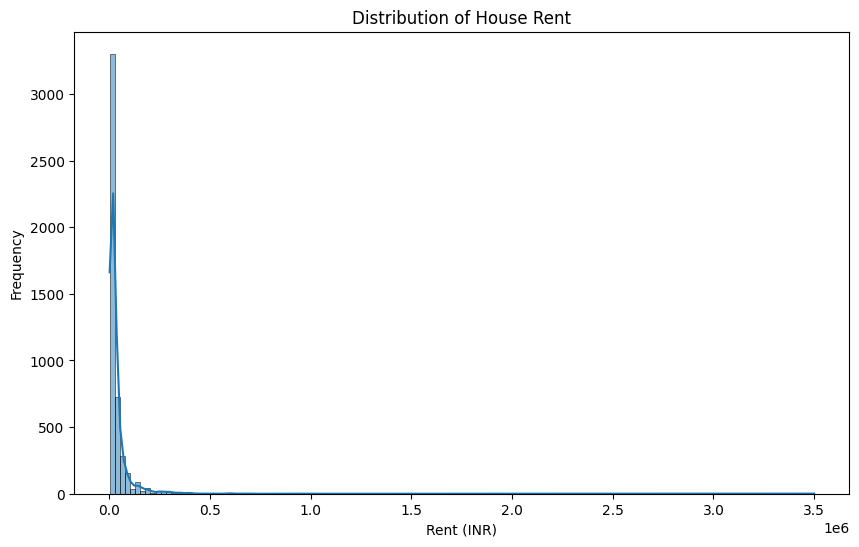

In [6]:
#Rent distribution plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df["Rent"], kde=True)
plt.title("Distribution of House Rent")
plt.xlabel("Rent (INR)")
plt.ylabel("Frequency")
plt.show()

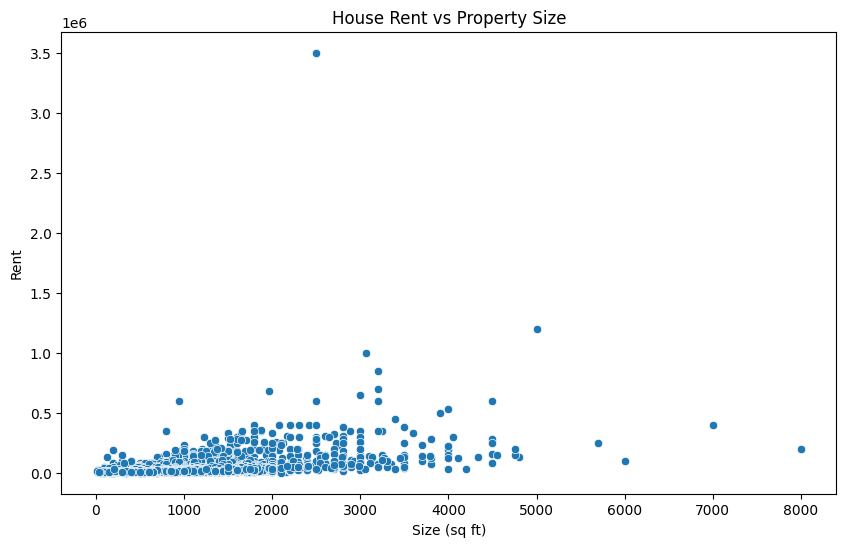

In [7]:
#Rent vs Size
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Size",
    y="Rent"
)
plt.title("House Rent vs Property Size")
plt.xlabel("Size (sq ft)")
plt.ylabel("Rent")
plt.show()

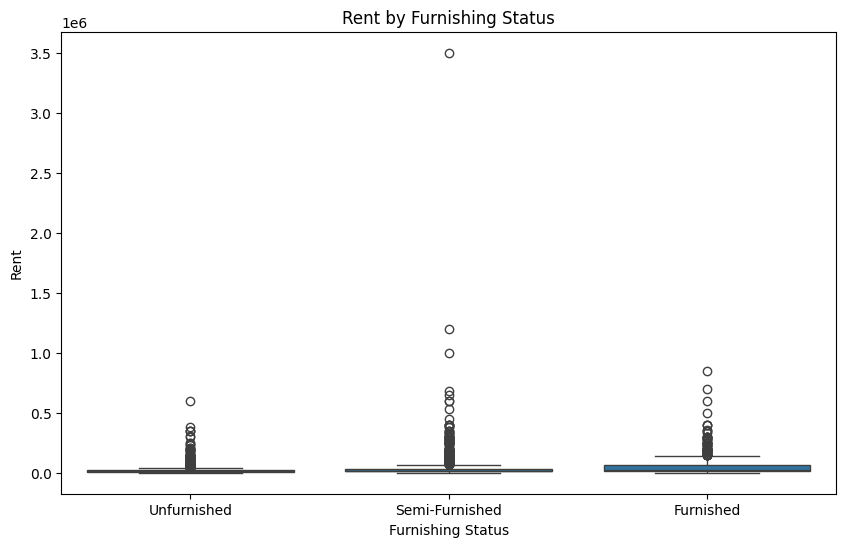

In [8]:
#Furnishing vs Rent
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="Furnishing Status",
    y="Rent"
)
plt.title("Rent by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Rent")
plt.show()

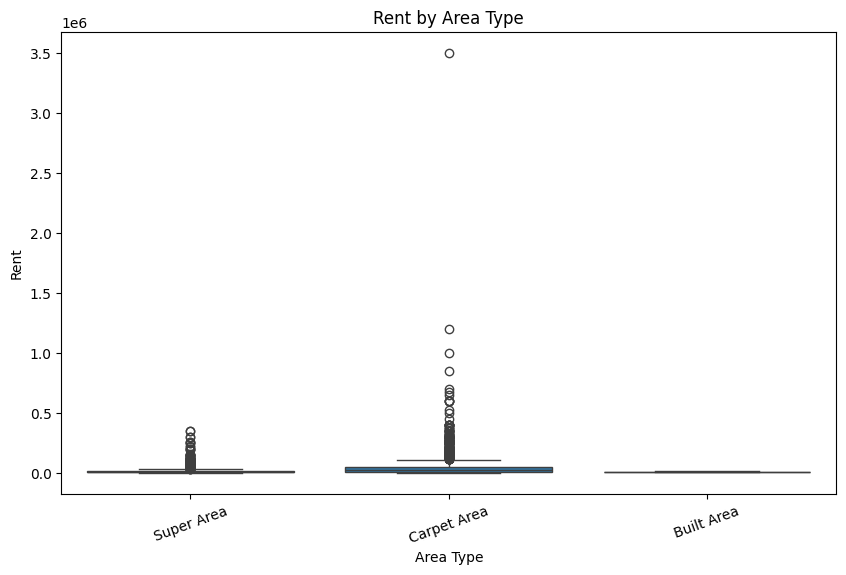

In [9]:
#Area Type vs Rent
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="Area Type",
    y="Rent"
)
plt.title("Rent by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Rent")
plt.xticks(rotation=20)
plt.show()